In [1]:
import os
import h5py
from temporaldata import Data

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

In [2]:
BIDS_ROOT = "/network/projects/neuro-galaxy/data/processed/neurosoft_minipigs_2026"
H5_FILENAME = "sub-02_ses-01_task-AcousticStim_desc-filtered_LH.h5"

### 1. Load .h5 file

In [3]:
with h5py.File(os.path.join(BIDS_ROOT, H5_FILENAME), "r") as f:
    data = Data.from_hdf5(f, lazy=False)
    
    print("Fields in data:")
    for key in data.keys():
        print("   - ", key)

Fields in data:
   -  acoustic_stim_trials
   -  brainset
   -  channels
   -  device
   -  ecog
   -  on_vs_off_trials
   -  session
   -  splits
   -  subject


### 2. Channels info

In [4]:
print("Channel names: ", data.channels.id)
print("Channel types: ", data.channels.type)

Channel names:  ['SG1D1E1' 'SG1D1E2' 'SG1D1E3' 'SG1D1E4' 'SG1D1E5' 'SG1D1E6' 'SG1D1E7'
 'SG1D1E8' 'SG1D1E9' 'SG1D1E10' 'SG1D1E11' 'SG1D1E12' 'SG1D1E13'
 'SG1D1E14' 'SG1D1E15' 'SG1D1E16' 'SG1D1E17' 'SG1D1E18' 'SG1D1E19'
 'SG1D1E20' 'SG1D1E21' 'SG1D1E22' 'SG1D1E23' 'SG1D1E24' 'N/A-6' 'N/A-7'
 'N/A-15' 'N/A-16' 'N/A-18' 'N/A-19' 'N/A-26' 'N/A-27']
Channel types:  ['ecog' 'ecog' 'ecog' 'ecog' 'ecog' 'ecog' 'ecog' 'ecog' 'ecog' 'ecog'
 'ecog' 'ecog' 'ecog' 'ecog' 'ecog' 'ecog' 'ecog' 'ecog' 'ecog' 'ecog'
 'ecog' 'ecog' 'ecog' 'ecog' 'misc' 'misc' 'misc' 'misc' 'misc' 'misc'
 'misc' 'misc']


### 3. iEEG data visualization

In [5]:
def plot_ieeg_signal(
    ieeg_signal,
    ch_names,
    ch_types,
    sampling_rate,
    interval=None,
    start_time=None,
    end_time=None,
    figsize=(15, 8),
):
    """
    Plots iEEG signal (stacked channels, black) with shaded interval regions indicating different labeled intervals.
    Instead of labeling intervals on top, uses a legend for the interval labels/colors.
    Args:
        ieeg_signal: n_channels x n_times or n_times x n_channels. Will transpose if needed.
        ch_names (list): Channel names.
        ch_types (list): Channel types (must match ch_names).
        sampling_rate (float): Sampling rate in Hz.
        interval (Interval): Interval object with start, end, and behavior_labels.
        start_time (float, optional): Start time for plotting window in seconds. Defaults to 0.
        end_time (float, optional): End time for plotting window in seconds. Defaults to end of signal.
        figsize (tuple): Figure size.
    """
    # Auto transpose to channels x time
    if ieeg_signal.shape[0] == len(ch_names):
        ecog_signal = ieeg_signal
    else:
        ecog_signal = ieeg_signal.T

    is_ecog = np.array([typ.lower() in ("ecog", "ieeg", "ecogv", "ecog_hgrid") for typ in ch_types])
    ch_names_used = np.array(ch_names)[is_ecog]
    ecog_signal = ecog_signal[is_ecog, :]
    n_channels = len(ch_names_used)
    n_samples = ecog_signal.shape[1]
    t = np.arange(n_samples) / sampling_rate
    
    # Handle time window filtering
    if start_time is None:
        start_time = 0
    
    idx = (t >= start_time)
    if end_time is not None:
        idx = idx & (t <= end_time)
    t = t[idx]
    ecog_signal = ecog_signal[:, idx]

    fig, ax = plt.subplots(figsize=figsize)
    offset = 5 * np.nanstd(ecog_signal)
    for ch_idx, ch_name in enumerate(ch_names_used):
        sig = ecog_signal[ch_idx]
        ax.plot(t, sig[:len(t)] + ch_idx * offset, color='black')

    ax.set_yticks(offset * np.arange(n_channels))
    ax.set_yticklabels(ch_names_used)
    ax.set_xlabel("Time (s)")
    ax.set_title("ECoG iEEG Signal with Intervals")
    ax.grid(True, axis="x", linestyle=":")

    if interval is not None:
        # Prepare intervals for coloring and legend
        interval_starts = np.array(interval.start)
        interval_ends = np.array(interval.end)
        interval_labels = np.array(interval.behavior_labels)
        n_intervals = len(interval_starts)

        # Assign distinct colors to unique labels using matplotlib tab10 palette (or fallback)
        unique_labels = np.unique(interval_labels)
        color_map = {}
        cmap = plt.get_cmap("tab10")
        for i, lbl in enumerate(unique_labels):
            color_map[lbl] = cmap(i % 10)

        # Only add one legend entry per label
        legend_handles = {}

        for i in range(n_intervals):
            s = interval_starts[i]  # start time in seconds
            e = interval_ends[i]    # end time in seconds
            lbl = interval_labels[i]
            # Skip intervals outside the time window
            if end_time is not None and s > end_time:
                continue
            if e < start_time:
                continue

            # Clip interval to the time window
            s = max(s, start_time)
            e = min(e, end_time) if end_time is not None else e
            shade_color = color_map[lbl]
            # vertical span over all traces (x-axis represents time in seconds)
            # Only add label to legend once
            legend_label = str(lbl) if legend_handles.get(lbl) is None else None
            ax.axvspan(
                s, e, color=shade_color, alpha=0.18, lw=0, label=legend_label
            )
            # Register legend handle if not already present
            if legend_label is not None:
                legend_handles[lbl] = Patch(facecolor=shade_color, alpha=0.18, label=legend_label, edgecolor='none')

        # Draw the legend (only if there are labels)
        if legend_handles:
            ax.legend(handles=list(legend_handles.values()), title="Interval Labels", loc="best", bbox_to_anchor=(1, 1))

    plt.tight_layout()
    plt.show()

In [6]:
# Example usage (uncomment to run):
signal = data.ecog.signal
ch_names = data.channels.id
ch_types = data.channels.type
sampling_rate = getattr(data.ecog, "sampling_rate", getattr(data.ecog, "sfreq", 1000))

# Trials
on_vs_off_trials = data.on_vs_off_trials
acoustic_stim_trials = data.acoustic_stim_trials

n_times, n_channels = signal.shape
recording_time = n_times / sampling_rate
print("recording time: ", recording_time, "seconds")
print("n_channels: ", n_channels)

recording time:  1710.5 seconds
n_channels:  32


In [7]:
start_time = 0  # seconds
end_time = 1700  # seconds

#### On (stim) vs Off (no stim) Task 

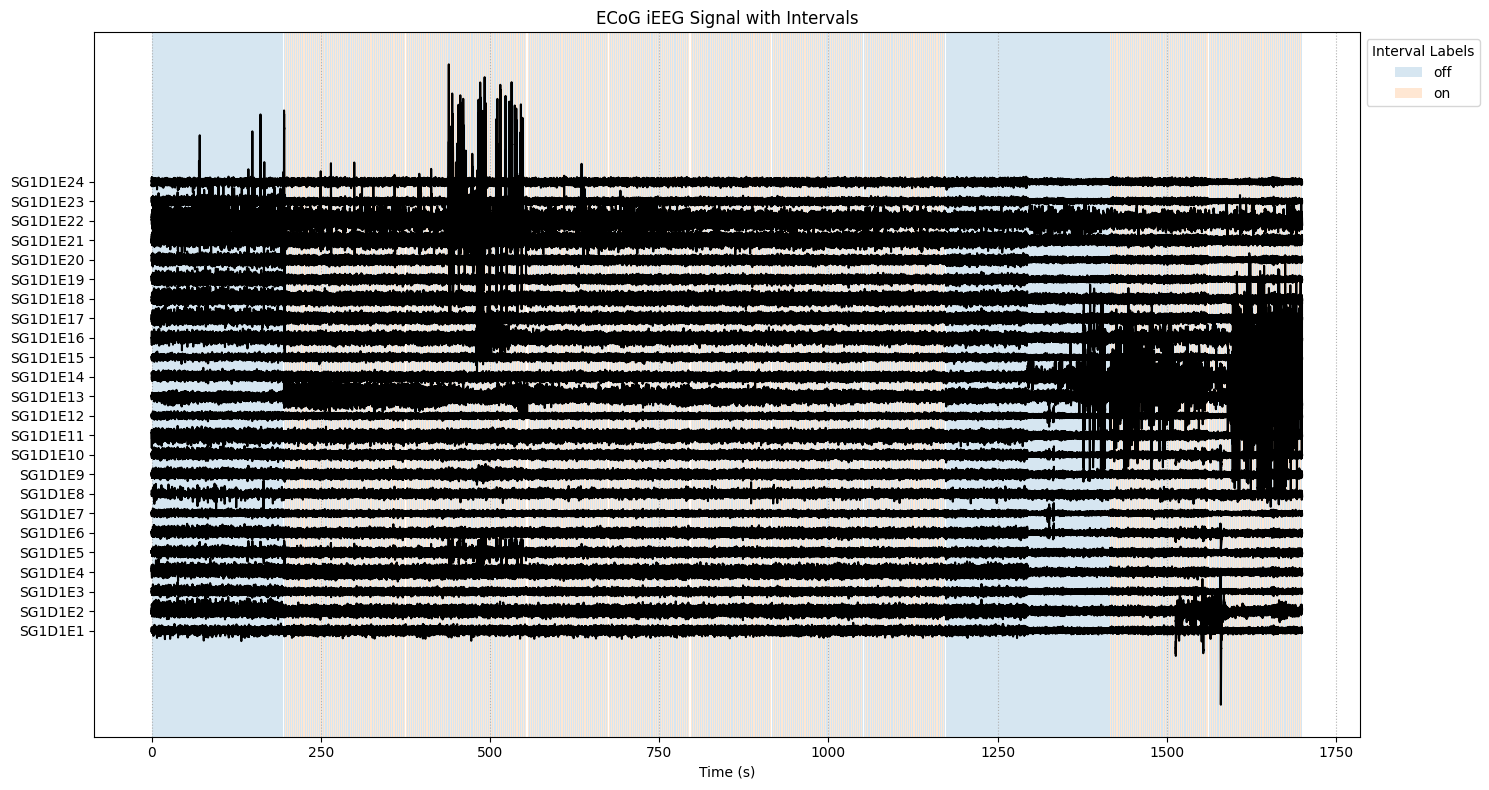

In [8]:
plot_ieeg_signal(
    signal.T,
    ch_names,
    ch_types,
    sampling_rate,
    interval=on_vs_off_trials,
    start_time=start_time,
    end_time=end_time,
    figsize=(15, 8),
)

#### Acoustic Stimulation Task 

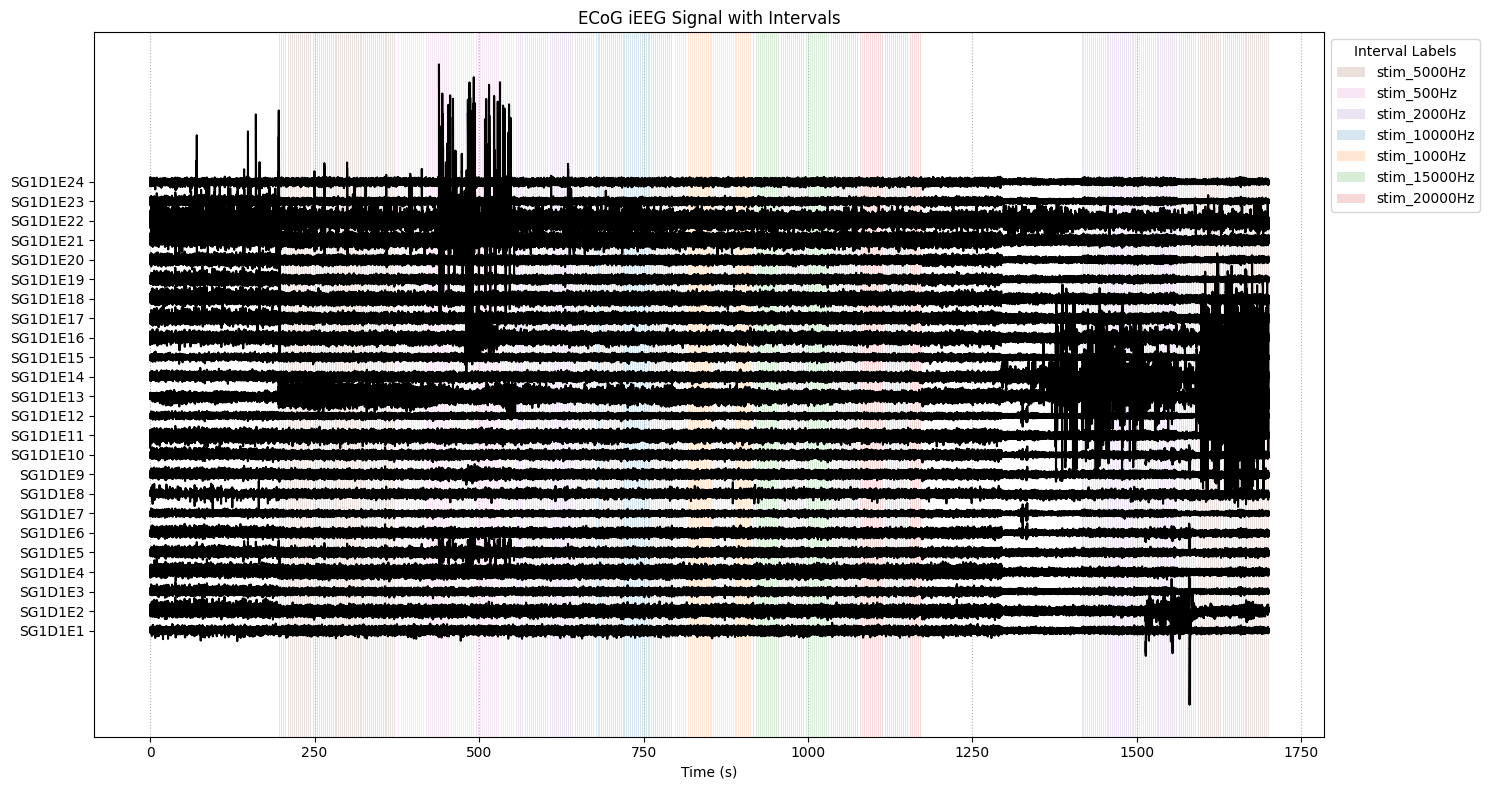

In [9]:
plot_ieeg_signal(
    signal.T,
    ch_names,
    ch_types,
    sampling_rate,
    interval=acoustic_stim_trials,
    start_time=start_time,
    end_time=end_time,
    figsize=(15, 8),
)